# Post-process charge data

## Install and import packages

In [2]:
!pip install --upgrade seaborn
!pip install plotly

  Using cached plotly-6.4.0-py3-none-any.whl.metadata (8.5 kB)
Using cached plotly-6.4.0-py3-none-any.whl (9.9 MB)


In [3]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns
import os

## Utils

In [4]:
# Set REASSIGN_CHARGE_MODE to True, in order to have a similar behaviour with the original dataset
REASSIGN_CHARGE_MODE = True

In [5]:
# Set SAVE equals to True, in order to Save cleaned charge data
SAVE = False

if SAVE:
    output_dir = f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/'
    file_path_csv = os.path.join(output_dir, f'EV_generated_data__charge_cleaned.csv')
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

## Data Inspection and Cleaning

### Load Synthetic Data

In [6]:
#### Load charge data
charge_data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')

number = 1200
#charge_data = pd.read_csv(f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_0_1EVpenalty/Generated_data/epoch_{number}/EV_generated_data_{number}.csv')
#charge_data = pd.read_csv(f'./Generated_data/epoch_{number}/EV_generated_data_{number}.csv')
#charge_data = pd.read_csv(f'.//Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')


# Add a column id to keep the number of the row
charge_data['id'] = charge_data.index
charge_data = charge_data[charge_data['event'] == 1].reset_index(drop=True)
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5773 entries, 0 to 5772
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event             5773 non-null   int64  
 1   charge_mode       5773 non-null   int64  
 2   duration_minutes  5773 non-null   float64
 3   km_driven         5773 non-null   float64
 4   charge            5773 non-null   float64
 5   id                5773 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 270.7 KB


In [6]:
charge_data.head(10)

,event,charge_mode,duration_minutes,km_driven,charge,id
0,1,0,343.974455,10.386721,6.919550,2
1,1,120,572.685302,7.041225,11.667474,3
2,1,240,67.938319,1.080015,9.237723,7
3,1,120,279.348466,3.530240,7.046600,8
4,1,360,25.854868,3.435789,27.472714,13
5,1,240,31.531805,1.533544,11.401076,14
6,1,120,192.479362,3.730621,4.792777,18
7,1,360,61.549824,4.616765,27.686187,20
8,1,120,37.469197,2.769128,7.304264,21
9,1,360,38.708399,1.900769,36.541806,26


### Data description

In [7]:
# Remove duplicates
init_len = len(charge_data)
charge_data = charge_data.drop_duplicates()

# Print how many records remain
print(f"Number of duplicates removed: {init_len - len(charge_data)}")

Number of duplicates removed: 0


In [8]:
# Check for missing values and print records with them
nan_count = charge_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

print("\n🔍 Records with missing values:\n")

records_with_nan = charge_data[charge_data.isna().any(axis=1)]

length = len(records_with_nan)
if length > 0:
    records_with_nan.head(length)

| Features | NaN-counter |
event               0
charge_mode         0
duration_minutes    0
km_driven           0
charge              0
id                  0
dtype: int64
|----------|-------------|

🔍 Records with missing values:



In [9]:
# main statistics of the dataset
charge_data['delta_soc'] = charge_data['charge']
print("Statistics of the dataset:")
charge_data[['duration_minutes', 'delta_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
duration_minutes,5773.0,144.314636,175.054510,12.935810,45.79681,74.872637,148.055918,1063.518371
delta_soc,5773.0,12.833520,9.993633,-7.888172,5.26299,8.833516,18.911921,38.921796


In [10]:
# Add min_per_perc_of_battery and charge_per_min
charge_data['min_per_perc_of_battery'] = charge_data.apply(
    lambda row: row['duration_minutes'] / row['charge'] if row['charge'] != 0 else 0,
    axis=1
)

charge_data['charge_per_min'] = charge_data.apply(
    lambda row: row['charge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)

#Print statistics
print('Statistics before post-processing')
print("\n🔋 Statistics on charge:\n", charge_data['charge'].describe())
print("\n🔋 Statistics on min_per_perc_of_battery:\n", charge_data['min_per_perc_of_battery'].describe())
print("\n🔋 Statistics on charge_per_min:\n", charge_data['charge_per_min'].describe())

Statistics before post-processing

🔋 Statistics on charge:
 count    5773.000000
mean       12.833520
std         9.993633
min        -7.888172
25%         5.262990
50%         8.833516
75%        18.911921
max        38.921796
Name: charge, dtype: float64

🔋 Statistics on min_per_perc_of_battery:
 count     5773.000000
mean        23.582447
std        318.701335
min     -14660.946900
25%          2.489621
50%          9.499657
75%         33.432981
max      13410.637614
Name: min_per_perc_of_battery, dtype: float64

🔋 Statistics on charge_per_min:
 count    5773.000000
mean        0.250239
std         0.304835
min        -0.014383
25%         0.029343
50%         0.101752
75%         0.388892
max         1.924247
Name: charge_per_min, dtype: float64


In [11]:
# Identify records with negative duration
negative_duration_records = charge_data[(charge_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
negative_duration_records.head(length)

Number of records with negative duration: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [12]:
# Remove records with negative duration
charge_data = charge_data.drop(negative_duration_records.index).reset_index(drop=True)

In [13]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = charge_data[(charge_data['charge'] == 0) & (charge_data['km_driven'] == 0) & (charge_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
snapshot_records.head(length)

Number of snapshot records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [14]:
# Remove snapshot records
charge_data = charge_data.drop(snapshot_records.index).reset_index(drop=True)

In [15]:
# Identify stationary records (data with no changes in soc, but positive duration)
stationary_records = charge_data[(charge_data['charge'] == 0) & (charge_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary rows: {length}")
stationary_records.head(length)

Number of stationary rows: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [16]:
# Remove stationary records
charge_data = charge_data.drop(stationary_records.index).reset_index(drop=True)

In [17]:
# Identify records with end_soc [%] < soc [%]   
anomalous_soc_records = charge_data[(charge_data['charge'] < 0)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
anomalous_soc_records.head(length)

Number of anomalous soc records: 40


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
22,1,0,325.072092,32.617021,-4.066372,58,-4.066372,-79.941548,-0.012509
26,1,0,381.838010,24.420058,-0.167471,67,-0.167471,-2280.025420,-0.000439
110,1,0,59.200923,4.473936,-0.535398,356,-0.535398,-110.573765,-0.009044
458,1,0,409.080289,31.775974,-2.526136,1368,-2.526136,-161.939108,-0.006175
555,1,0,550.188557,45.609979,-5.916526,1681,-5.916526,-92.991824,-0.010754
563,1,0,694.277053,36.478042,-2.717561,1717,-2.717561,-255.478042,-0.003914
924,1,0,336.510661,22.498339,-0.193750,2848,-0.193750,-1736.827186,-0.000576
1141,1,0,284.206512,28.838525,-3.395784,3506,-3.395784,-83.693926,-0.011948
1216,1,0,123.010277,9.257955,-0.541010,3803,-0.541010,-227.371627,-0.004398
1371,1,0,548.427958,49.135339,-7.888172,4223,-7.888172,-69.525357,-0.014383


In [18]:
# Remove anomalous soc records
charge_data = charge_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [19]:
# Identify records with high charge per minute
###########################
MAX_CHARGE_PER_MIN = 1.10 #
###########################


anomalous_charge_records = charge_data[(charge_data['charge_per_min'] > MAX_CHARGE_PER_MIN)]

length = anomalous_charge_records.shape[0]
print(f"Number of records with charge per minute > {MAX_CHARGE_PER_MIN}: {length}")
anomalous_charge_records.head(length)

Number of records with charge per minute > 1.1: 119


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
37,1,360,31.491926,2.289331,36.750608,123,36.750608,0.856909,1.166985
53,1,360,26.413292,2.053686,29.118000,164,29.118000,0.907112,1.102400
97,1,360,23.875430,3.258352,29.212101,314,29.212101,0.817313,1.223521
250,1,360,22.057308,3.156859,27.162883,748,27.162883,0.812039,1.231469
263,1,360,23.974652,2.077003,34.293603,805,34.293603,0.699100,1.430411
...,...,...,...,...,...,...,...,...,...
5487,1,360,31.526672,2.035467,37.149435,16653,37.149435,0.848645,1.178349
5601,1,240,16.536492,4.157190,25.213054,16986,25.213054,0.655870,1.524692
5662,1,360,24.362886,3.004106,29.452936,17186,29.452936,0.827180,1.208926
5670,1,360,26.957771,1.881713,30.614970,17216,30.614970,0.880542,1.135664


In [20]:
# Remove anomalous charge records
charge_data = charge_data.drop(anomalous
    _charge_records.index).reset_index(drop=True)

In [20]:
# Identify records with low charge per minute
###########################
MIN_CHARGE_PER_MIN = 0.005 #
###########################


anomalous_charge_records = charge_data[(charge_data['charge_per_min'] < MIN_CHARGE_PER_MIN)]

length = anomalous_charge_records.shape[0]
print(f"Number of records with charge per minute < {MIN_CHARGE_PER_MIN}: {length}")
anomalous_charge_records.head(length)

Number of records with charge per minute < 0.005: 45


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
149,1,0,583.072347,26.414153,0.679453,444,0.679453,858.149582,0.001165
298,1,0,131.533500,10.466280,0.463307,908,0.463307,283.901522,0.003522
416,1,120,958.419079,35.848691,0.822007,1265,0.822007,1165.949555,0.000858
518,1,0,183.116293,16.354831,0.341261,1590,0.341261,536.586711,0.001864
535,1,120,1004.593165,37.743873,1.469938,1629,1.469938,683.425445,0.001463
547,1,0,679.363644,27.337369,1.111496,1673,1.111496,611.215678,0.001636
709,1,0,400.757610,25.048186,0.780990,2184,0.780990,513.140734,0.001949
770,1,0,515.832786,30.347364,0.741263,2379,0.741263,695.883957,0.001437
774,1,0,286.130569,18.914923,0.829393,2385,0.829393,344.987852,0.002899
806,1,0,77.481120,5.577756,0.104065,2512,0.104065,744.545512,0.001343


In [21]:
# Remove anomalous charge records
charge_data = charge_data.drop(anomalous_charge_records.index).reset_index(drop=True)

In [22]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5688 entries, 0 to 5687
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event                    5688 non-null   int64  
 1   charge_mode              5688 non-null   int64  
 2   duration_minutes         5688 non-null   float64
 3   km_driven                5688 non-null   float64
 4   charge                   5688 non-null   float64
 5   id                       5688 non-null   int64  
 6   delta_soc                5688 non-null   float64
 7   min_per_perc_of_battery  5688 non-null   float64
 8   charge_per_min           5688 non-null   float64
dtypes: float64(6), int64(3)
memory usage: 400.1 KB


In [23]:
#Print statistics
print('Statistics after post-processing')
print("\n🔋 Statistics on charge:\n", charge_data['charge'].describe())
print("\n🔋 Statistics on min_per_perc_of_battery:\n", charge_data['min_per_perc_of_battery'].describe())
print("\n🔋 Statistics on charge_per_min:\n", charge_data['charge_per_min'].describe())

Statistics after post-processing

🔋 Statistics on charge:
 count    5688.000000
mean       13.034697
std         9.927382
min         0.469710
25%         5.377666
50%         8.998128
75%        19.290219
max        38.921796
Name: charge, dtype: float64

🔋 Statistics on min_per_perc_of_battery:
 count    5688.000000
mean       20.524003
std        25.135697
min         0.519684
25%         2.516695
50%         9.475545
75%        32.974561
max       199.362265
Name: min_per_perc_of_battery, dtype: float64

🔋 Statistics on charge_per_min:
 count    5688.000000
mean        0.253996
std         0.305539
min         0.005016
25%         0.030326
50%         0.105535
75%         0.397346
max         1.924247
Name: charge_per_min, dtype: float64


### Charge_mode re-assignment

In [24]:
if REASSIGN_CHARGE_MODE:
    # Print max charge_data_original['charge_per_min'] when '120' is in charge_data_original['charge_mode'], when '240' is in charge_mode and when 'DC' is in chrge_mode
    result = charge_data.groupby("charge_mode")["charge_per_min"].max()
    print(result)

charge_mode
0      0.171345
120    0.956934
240    1.924247
360    1.901889
Name: charge_per_min, dtype: float64


In [25]:
if REASSIGN_CHARGE_MODE:
    # ORIGINAL Thresholds
    max_120 = 0.04
    max_240 = 0.16
    
    
    # Conditions
    conditions = [
        charge_data['charge_per_min'] <= max_120,
        (charge_data['charge_per_min'] > max_120) & (charge_data['charge_per_min'] <= max_240)
    ]
    
    # Values to assign
    values = [120, 240]
    
    # Default value if none of the conditions match
    charge_data['charge_mode'] = np.select(conditions, values, default=360)
    
    charge_data.head(30)

## Data Visualization and Comparative Analysis

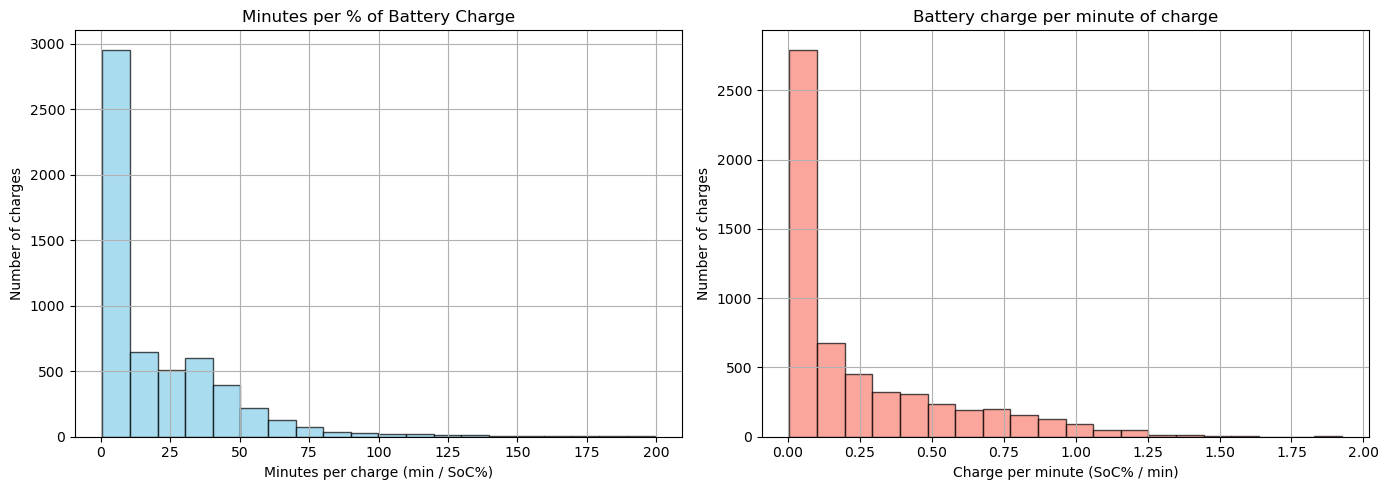

In [26]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Minutes per % battery
axes[0].hist(
    charge_data['min_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Minutes per % of Battery Charge')
axes[0].set_xlabel('Minutes per charge (min / SoC%)')
axes[0].set_ylabel('Number of charges')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    charge_data['charge_per_min'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery charge per minute of charge')
axes[1].set_xlabel('Charge per minute (SoC% / min)')
axes[1].set_ylabel('Number of charges')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [27]:
charge_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
0,1,120,343.974455,10.386721,6.919550,2,6.919550,49.710522,0.020116
1,1,120,572.685302,7.041225,11.667474,3,11.667474,49.083915,0.020373
2,1,240,67.938319,1.080015,9.237723,7,9.237723,7.354444,0.135972
3,1,120,279.348466,3.530240,7.046600,8,7.046600,39.643014,0.025225
4,1,360,25.854868,3.435789,27.472714,13,27.472714,0.941111,1.062574


In [28]:
max_min = charge_data['min_per_perc_of_battery'].max()
max_min_row = charge_data[charge_data['min_per_perc_of_battery'] == max_min]

print("\n Record with maximum min/SoC:\n")
max_min_row.head()


 Record with maximum min/SoC:



,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
3292,1,120,499.113067,21.884241,2.503548,10088,2.503548,199.362265,0.005016


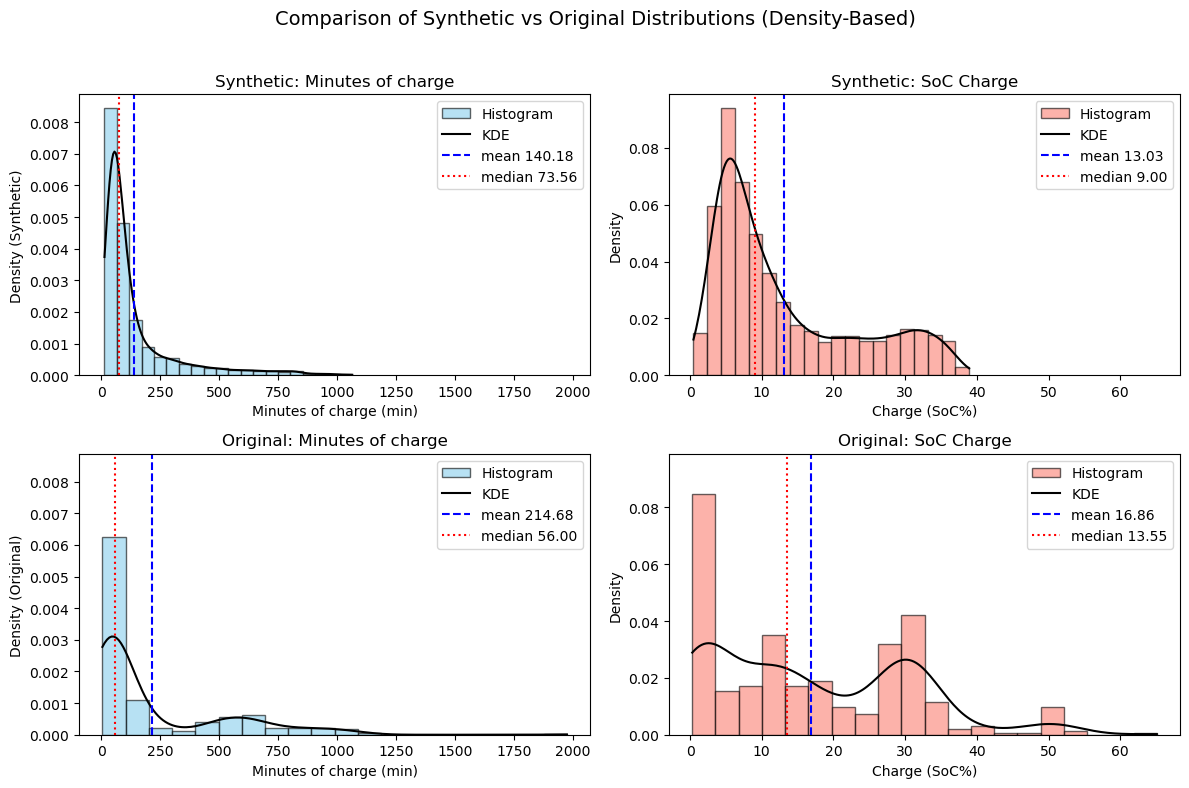

In [45]:
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20, density=True):
    # Ensure numeric and drop NaNs / infs
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return

    # Histogram as DENSITY
    counts, bin_edges, _ = ax.hist(y, bins=bins, density=density,
                                   alpha=0.6, color=color, edgecolor='black', label='Histogram')

    # KDE on density scale
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        kde_vals = kde(x_grid)
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass

    # Mean & median vertical lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend()

# --- Create figure with 2 rows (synthetic on top, original on bottom) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='col')

# Synthetic data (top row)
plot_hist_with_kde(charge_data.get('duration_minutes', pd.Series(dtype=float)), axes[0, 0],
                   color='skyblue', title='Synthetic: Minutes of charge', xlabel='Minutes of charge (min)')

plot_hist_with_kde(charge_data.get('charge', pd.Series(dtype=float)), axes[0, 1],
                   color='salmon', title='Synthetic: SoC Charge', xlabel='Charge (SoC%)')

# Original data (bottom row)
plot_hist_with_kde(charge_data_original.get('duration_minutes', pd.Series(dtype=float)), axes[1, 0],
                   color='skyblue', title='Original: Minutes of charge', xlabel='Minutes of charge (min)')

plot_hist_with_kde(charge_data_original.get('charge', pd.Series(dtype=float)), axes[1, 1],
                   color='salmon', title='Original: SoC Charge', xlabel='Charge (SoC%)')

# --- Match axes scales explicitly between synthetic and original ---
for j in range(2):
    xmin = min(axes[0, j].get_xlim()[0], axes[1, j].get_xlim()[0])
    xmax = max(axes[0, j].get_xlim()[1], axes[1, j].get_xlim()[1])
    ymin = min(axes[0, j].get_ylim()[0], axes[1, j].get_ylim()[0])
    ymax = max(axes[0, j].get_ylim()[1], axes[1, j].get_ylim()[1])
    axes[0, j].set_xlim(xmin, xmax)
    axes[1, j].set_xlim(xmin, xmax)
    axes[0, j].set_ylim(ymin, ymax)
    axes[1, j].set_ylim(ymin, ymax)

# --- Show x-axis tick labels for top plots too ---
for ax in axes[0, :]:
    ax.tick_params(labelbottom=True)

# --- Formatting ---
axes[0, 0].set_ylabel("Density (Synthetic)")
axes[1, 0].set_ylabel("Density (Original)")
fig.suptitle("Comparison of Synthetic vs Original Distributions (Density-Based)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

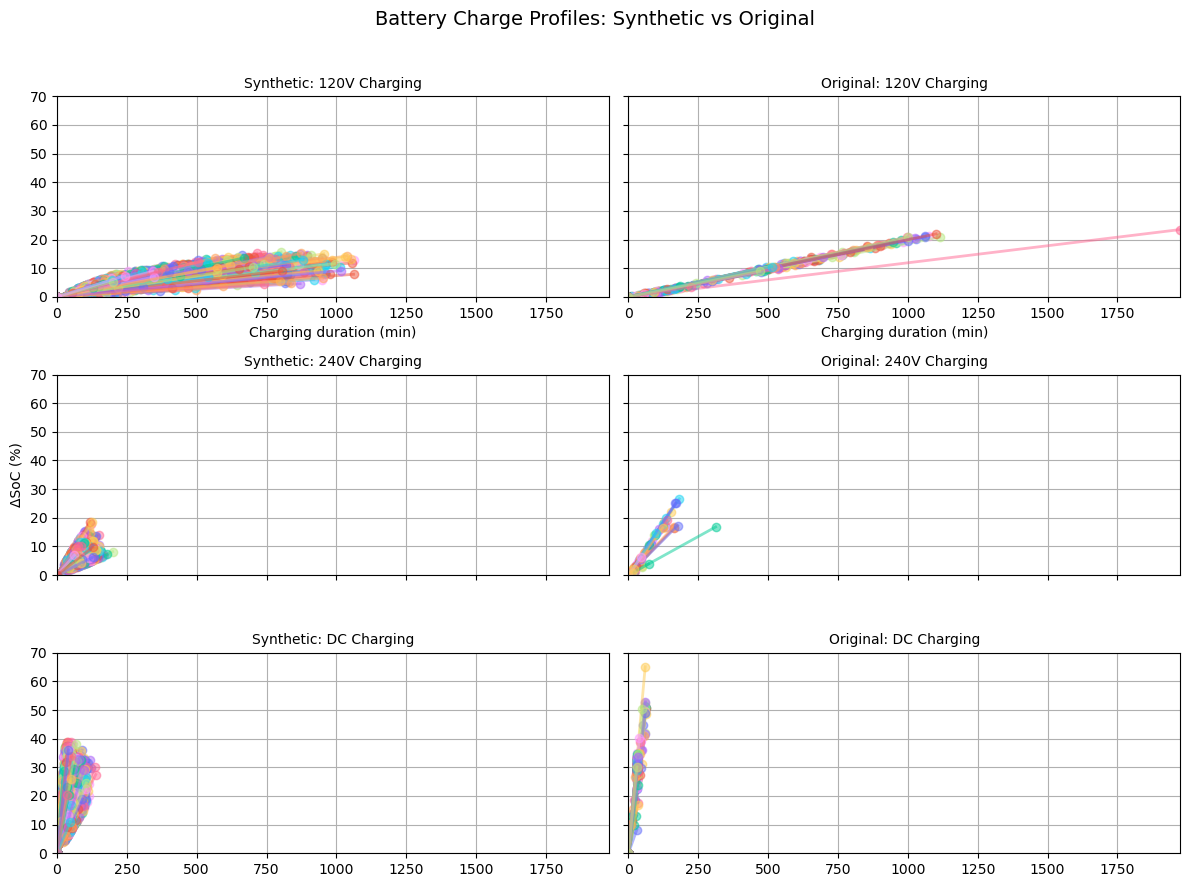

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

# --- Synthetic data prep ---
charge_data = charge_data.copy()
charge_data['delta_soc'] = charge_data['charge']  # already ΔSoC
charge_data['soc'] = 0
charge_data['end_soc'] = charge_data['delta_soc']

# --- Original data prep ---
charge_data_original = charge_data_original.copy()
charge_data_original['delta_soc'] = (
    charge_data_original['end_soc'] - charge_data_original['soc']
)
charge_data_original['soc'] = 0
charge_data_original['end_soc'] = charge_data_original['delta_soc']

# --- Shared scales ---
max_minutes = max(
    charge_data['duration_minutes'].max(),
    charge_data_original['duration_minutes'].max()
)
max_soc = 70  # y-limit

# --- Colors ---
colors = px.colors.qualitative.Plotly
n_colors = len(colors)

# --- Mode mapping ---
mode_titles = {
    '120': ('Synthetic: 120V Charging', 'Original: 120V Charging'),
    '240': ('Synthetic: 240V Charging', 'Original: 240V Charging'),
    'DC':  ('Synthetic: DC Charging', 'Original: DC Charging')
}

# --- Figure setup ---
fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(12, 9),
    sharex=True, sharey=True
)

# --- Loop through modes ---
for i, (key, (title_syn, title_orig)) in enumerate(mode_titles.items()):

    # --- Filter synthetic (numeric codes) ---
    if key == 'DC':
        syn = charge_data[charge_data['charge_mode'] == 360]
    else:
        syn = charge_data[charge_data['charge_mode'] == int(key)]

    # --- Filter original (string-based modes) ---
    if key == 'DC':
        orig = charge_data_original[
            charge_data_original['charge_mode'].astype(str).str.contains('DC', case=False, na=False)
        ]
    else:
        orig = charge_data_original[
            charge_data_original['charge_mode'].astype(str).str.contains(key, case=False, na=False)
        ]

    # --- LEFT: Synthetic ---
    ax_syn = axes[i, 0]
    for j, (_, row) in enumerate(syn.iterrows()):
        ax_syn.plot(
            [0, row['duration_minutes']],
            [0, row['end_soc']],  # always start from 0
            marker='o',
            alpha=0.5,
            color=colors[j % n_colors],
            linewidth=2
        )
    ax_syn.set_title(title_syn, fontsize=10)
    ax_syn.grid(True)
    ax_syn.set_xlim(0, max_minutes)
    ax_syn.set_ylim(0, max_soc)
    if i == 1:
        ax_syn.set_ylabel("ΔSoC (%)")

    # --- RIGHT: Original ---
    ax_orig = axes[i, 1]
    for j, (_, row) in enumerate(orig.iterrows()):
        ax_orig.plot(
            [0, row['duration_minutes']],
            [0, row['end_soc']],  # always start from 0
            marker='o',
            alpha=0.5,
            color=colors[j % n_colors],
            linewidth=2
        )
    ax_orig.set_title(title_orig, fontsize=10)
    ax_orig.grid(True)
    ax_orig.set_xlim(0, max_minutes)
    ax_orig.set_ylim(0, max_soc)

# --- Shared ----
for ax in axes[0, :]:
    ax.set_xlabel("Charging duration (min)")
    ax.tick_params(labelbottom=True)

fig.suptitle("Battery Charge Profiles: Synthetic vs Original", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [31]:
charge_data['charge_per_min'].describe()

count    5688.000000
mean        0.253996
std         0.305539
min         0.005016
25%         0.030326
50%         0.105535
75%         0.397346
max         1.924247
Name: charge_per_min, dtype: float64

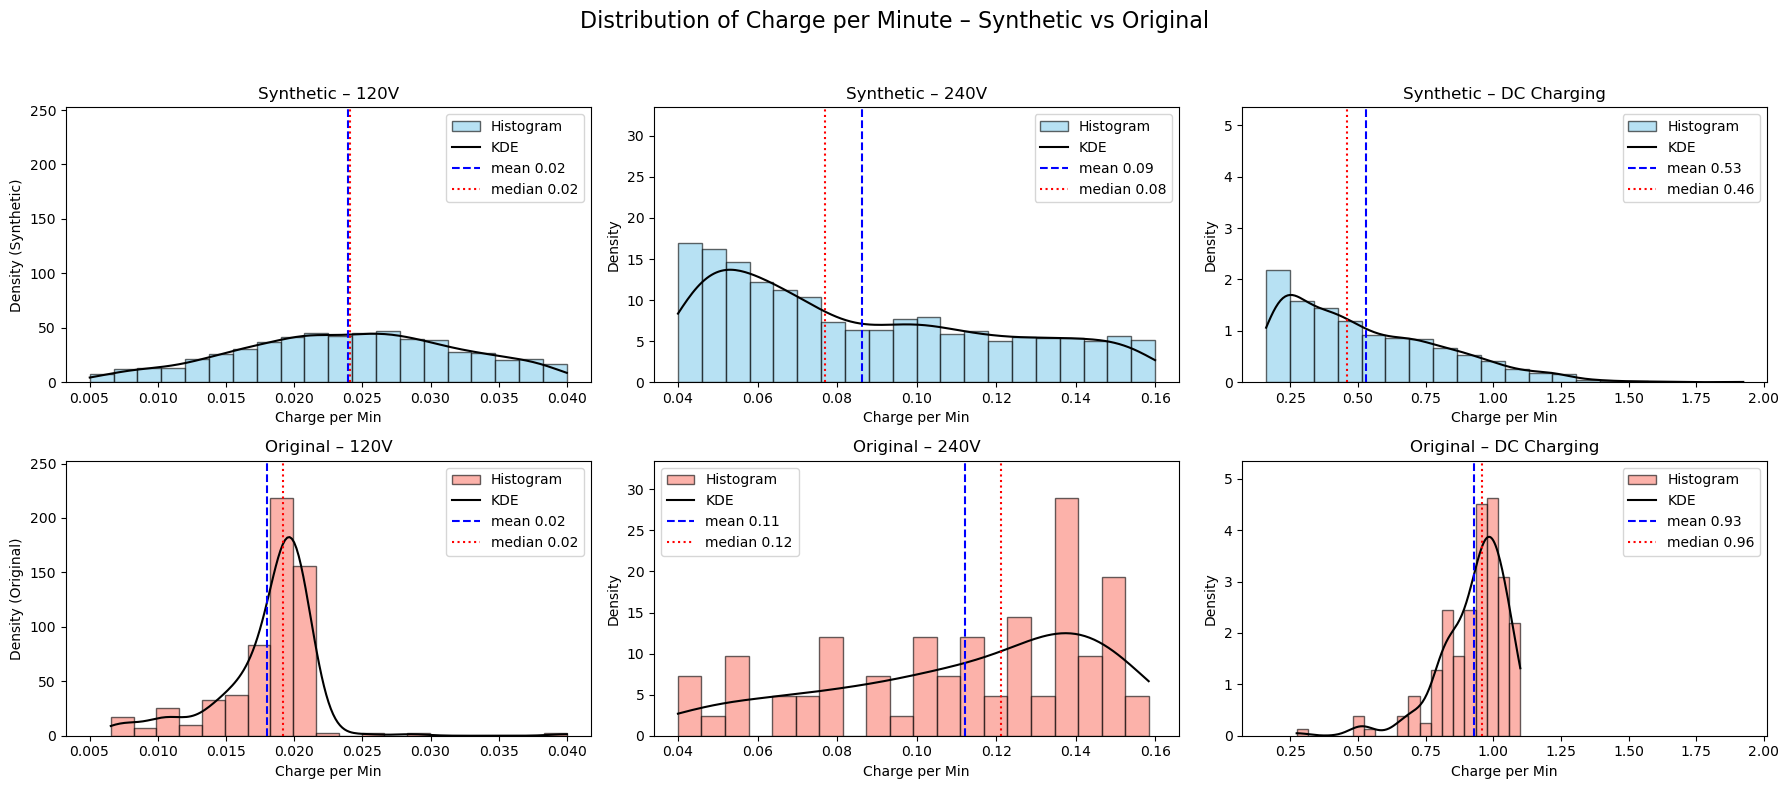

In [52]:
# --- Distribution of Charge per Min: Synthetic vs Original ---

# Map charge_mode values to labels
charge_labels = {120: "120V", 240: "240V", 360: "DC Charging"}

# Figure setup: 2 rows (synthetic/original) × 3 columns (charge modes)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))  # no sharex or sharey now

for i, mode in enumerate([120, 240, 360]):
    # --- Synthetic ---
    data_syn = charge_data.loc[charge_data['charge_mode'] == mode, 'charge_per_min']
    ax_syn = axes[0, i]
    plot_hist_with_kde(
        data_syn,
        ax=ax_syn,
        color='skyblue',
        title=f"Synthetic – {charge_labels[mode]}",
        xlabel='Charge per Min'
    )

    # --- Original ---
    if mode == 360:
        mask_orig = charge_data_original['charge_mode'].astype(str).str.contains('DC', case=False, na=False)
    else:
        mask_orig = charge_data_original['charge_mode'].astype(str).str.contains(str(mode), case=False, na=False)
    data_orig = charge_data_original.loc[mask_orig, 'charge_per_min']

    ax_orig = axes[1, i]
    plot_hist_with_kde(
        data_orig,
        ax=ax_orig,
        color='salmon',
        title=f"Original – {charge_labels[mode]}",
        xlabel='Charge per Min'
    )

    # --- Smart x-axis per column ---
    all_data = pd.concat([data_syn, data_orig]).dropna()
    if not all_data.empty:
        xmin, xmax = all_data.min(), all_data.max()
        xmargin = (xmax - xmin) * 0.05
        ax_syn.set_xlim(xmin - xmargin, xmax + xmargin)
        ax_orig.set_xlim(xmin - xmargin, xmax + xmargin)

    # --- Smart y-axis per column ---
    ymax_vals = [ax_syn.get_ylim()[1], ax_orig.get_ylim()[1]]
    ymax = max(ymax_vals) * 1.1  # 10% padding
    ax_syn.set_ylim(0, ymax)
    ax_orig.set_ylim(0, ymax)

# --- Common labels ---
axes[0, 0].set_ylabel('Density (Synthetic)')
axes[1, 0].set_ylabel('Density (Original)')

fig.suptitle("Distribution of Charge per Minute – Synthetic vs Original", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


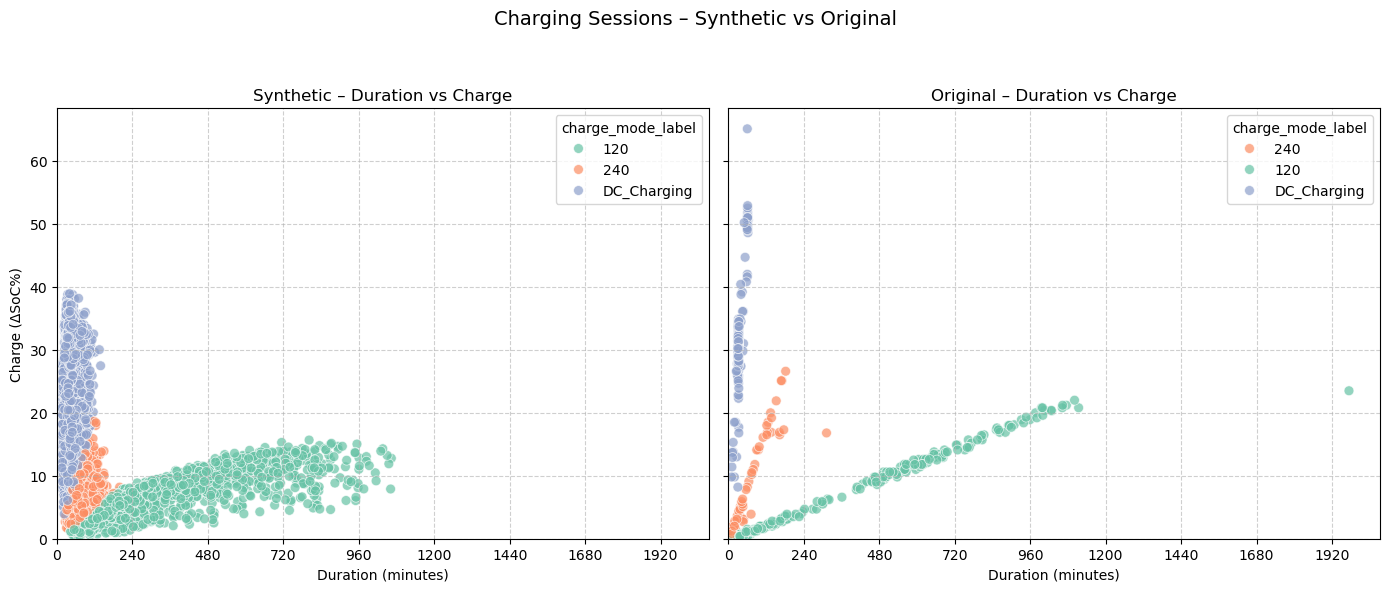

In [61]:
# --- Copy to avoid modifying originals ---
charge_data_syn = charge_data.copy()
charge_data_orig = charge_data_original.copy()

# --- Normalize charge_mode labels for consistency ---
def normalize_label_syn(val):
    if val == 120:
        return '120'
    elif val == 240:
        return '240'
    elif val == 360:
        return 'DC_Charging'
    else:
        return None

def normalize_label_orig(val):
    s = str(val).strip().lower()
    if 'dc' in s:
        return 'DC_Charging'
    elif '120' in s:
        return '120'
    elif '240' in s:
        return '240'
    else:
        return None

charge_data_syn['charge_mode_label'] = charge_data_syn['charge_mode'].apply(normalize_label_syn)
charge_data_orig['charge_mode_label'] = charge_data_orig['charge_mode'].apply(normalize_label_orig)

# --- Define consistent color palette ---
fixed_palette = {
    "120": "#66c2a5",        # greenish
    "240": "#fc8d62",        # orange
    "DC_Charging": "#8da0cb" # blue
}

# --- Shared axis limits for fair comparison ---
max_duration = max(
    charge_data_syn['duration_minutes'].max(),
    charge_data_orig['duration_minutes'].max()
)
max_charge = max(
    charge_data_syn['charge'].max(),
    charge_data_orig['charge'].max()
)

# --- Create side-by-side subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# ==========================================================
# LEFT: Synthetic
# ==========================================================
sns.scatterplot(
    data=charge_data_syn,
    x='duration_minutes',
    y='charge',
    hue='charge_mode_label',
    palette=fixed_palette,
    s=50,
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("Synthetic – Duration vs Charge", fontsize=12)
axes[0].set_xlim(0, max_duration * 1.05)
axes[0].set_ylim(0, max_charge * 1.05)
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Charge (ΔSoC%)")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(60))

# ==========================================================
# RIGHT: Original
# ==========================================================
sns.scatterplot(
    data=charge_data_orig,
    x='duration_minutes',
    y='charge',
    hue='charge_mode_label',
    palette=fixed_palette,
    s=50,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("Original – Duration vs Charge", fontsize=12)
axes[1].set_xlim(0, max_duration * 1.05)
axes[1].set_ylim(0, max_charge * 1.05)
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(240))



# --- Final layout ---
fig.suptitle("Charging Sessions – Synthetic vs Original", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [34]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5688 entries, 0 to 5687
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event                    5688 non-null   int64  
 1   charge_mode              5688 non-null   int64  
 2   duration_minutes         5688 non-null   float64
 3   km_driven                5688 non-null   float64
 4   charge                   5688 non-null   float64
 5   id                       5688 non-null   int64  
 6   delta_soc                5688 non-null   float64
 7   min_per_perc_of_battery  5688 non-null   float64
 8   charge_per_min           5688 non-null   float64
 9   soc                      5688 non-null   int64  
 10  end_soc                  5688 non-null   float64
 11  charge_mode_label        5688 non-null   object 
dtypes: float64(7), int64(4), object(1)
memory usage: 533.4+ KB


## Original dataset

In [35]:
charge_data_original = pd.read_csv('./datasets/new2_vehicle_2_47174e+18.csv')
#charge_data_original = pd.read_csv('./datasets/EV_data.csv')

charge_data_original = charge_data_original[charge_data_original['event'] == 'charge'].reset_index(drop=True)
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543 entries, 0 to 542
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          543 non-null    float64
 1   timestamp    543 non-null    object 
 2   end_time     543 non-null    object 
 3   odo          543 non-null    float64
 4   end_odo      543 non-null    float64
 5   soc          543 non-null    float64
 6   end_soc      543 non-null    float64
 7   event        543 non-null    object 
 8   charge_mode  543 non-null    object 
dtypes: float64(5), object(4)
memory usage: 38.3+ KB


In [36]:
# Count number of entries for each charge_mode
counts = charge_data_original['charge_mode'].value_counts()

print(counts)

charge_mode
120           249
DCCharging    214
240            72
0               8
Name: count, dtype: int64


In [37]:
# Remove duplicates
charge_data_original = charge_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(charge_data_original)}")

charge_data_original['charge'] = charge_data_original['end_soc'] - charge_data_original['soc']
charge_data_original['discharge'] = charge_data_original['soc'] - charge_data_original['end_soc']

# Convert timestamps to datetime
charge_data_original['timestamp'] = pd.to_datetime(charge_data_original['timestamp'], errors='coerce')
charge_data_original['end_time'] = pd.to_datetime(charge_data_original['end_time'], errors='coerce')

# Compute event duration in minutes
charge_data_original['duration_minutes'] = (charge_data_original['end_time'] - charge_data_original['timestamp']).dt.total_seconds() / 60

print("\n🔋 Statistics on Charge:\n", charge_data_original['charge'].describe())

Number of rows after removing duplicates: 516

🔋 Statistics on Charge:
 count    516.000000
mean      17.133527
std       13.898268
min        0.300000
25%        3.175000
50%       13.950000
75%       29.400000
max       65.100000
Name: charge, dtype: float64


In [38]:
charge_data_original['min_per_perc_of_battery'] = charge_data_original.apply(
    lambda row: row['duration_minutes'] / -row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

charge_data_original['charge_per_min'] = charge_data_original.apply(
    lambda row: -row['discharge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)


In [39]:
MAX_CHARGE_PER_MIN = 1.10
##########################################################



anomalous_rows_charge = charge_data_original[(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)]
print(f"Number of anamalous rows: {anomalous_rows_charge.shape[0]}")

charge_data_original = charge_data_original[~(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)].reset_index(drop=True)
anomalous_rows_charge.head(len(anomalous_rows_charge ))

Number of anamalous rows: 12


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,charge,discharge,duration_minutes,min_per_perc_of_battery,charge_per_min
0,-2.471740e+18,2021-04-29 10:46:00,2021-04-29 11:17:00,2286.71875,2286.734375,24.3,59.2,charge,DCCharging,34.9,-34.9,31.0,0.888252,1.125806
112,-2.471740e+18,2021-06-07 22:55:00,2021-06-07 23:26:00,11661.75000,11661.750000,29.8,65.0,charge,DCCharging,35.2,-35.2,31.0,0.880682,1.135484
155,-2.471740e+18,2021-06-19 00:21:00,2021-06-19 00:51:00,15289.43750,15289.437500,29.8,64.3,charge,DCCharging,34.5,-34.5,30.0,0.869565,1.150000
223,-2.471740e+18,2021-07-15 20:12:00,2021-07-15 20:27:00,22365.68750,22365.687500,28.2,44.7,charge,DCCharging,16.5,-16.5,15.0,0.909091,1.100000
387,-2.471740e+18,2021-08-17 19:52:00,2021-08-17 20:09:00,34609.67188,34609.671880,29.8,50.9,charge,DCCharging,21.1,-21.1,17.0,0.805687,1.241176
390,-2.471740e+18,2021-08-18 13:57:00,2021-08-18 14:28:00,34909.48438,34909.484380,37.2,72.5,charge,DCCharging,35.3,-35.3,31.0,0.878187,1.138710
391,-2.471740e+18,2021-08-18 21:29:00,2021-08-18 22:04:00,35093.70313,35093.703130,37.2,76.8,charge,DCCharging,39.6,-39.6,35.0,0.883838,1.131429
394,-2.471740e+18,2021-08-19 15:57:00,2021-08-19 16:15:00,35501.14063,35501.140630,43.1,63.1,charge,DCCharging,20.0,-20.0,18.0,0.900000,1.111111
413,-2.471740e+18,2021-08-25 16:29:00,2021-08-25 16:41:00,37669.50000,37669.500000,30.9,48.6,charge,DCCharging,17.7,-17.7,12.0,0.677966,1.475000
453,-2.471740e+18,2021-09-07 01:55:00,2021-09-07 02:40:00,41677.68750,41677.687500,27.4,81.1,charge,DCCharging,53.7,-53.7,45.0,0.837989,1.193333


In [40]:
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   vin                      504 non-null    float64       
 1   timestamp                504 non-null    datetime64[ns]
 2   end_time                 504 non-null    datetime64[ns]
 3   odo                      504 non-null    float64       
 4   end_odo                  504 non-null    float64       
 5   soc                      504 non-null    float64       
 6   end_soc                  504 non-null    float64       
 7   event                    504 non-null    object        
 8   charge_mode              504 non-null    object        
 9   charge                   504 non-null    float64       
 10  discharge                504 non-null    float64       
 11  duration_minutes         504 non-null    float64       
 12  min_per_perc_of_battery  504 non-nul

In [41]:
charge_data_original['charge_per_min'].describe()

count    504.000000
mean       0.379533
std        0.440543
min        0.006557
25%        0.019343
50%        0.072727
75%        0.909677
max        1.100000
Name: charge_per_min, dtype: float64

In [42]:
# Print max charge_data_original['charge_per_min'] when '120' is in charge_data_original['charge_mode'], when '240' is in charge_mode and when 'DC' is in charge_mode
result = charge_data_original.groupby("charge_mode")["charge_per_min"].max()
print(result)

charge_mode
0             1.006667
120           0.040000
240           0.158333
DCCharging    1.100000
Name: charge_per_min, dtype: float64


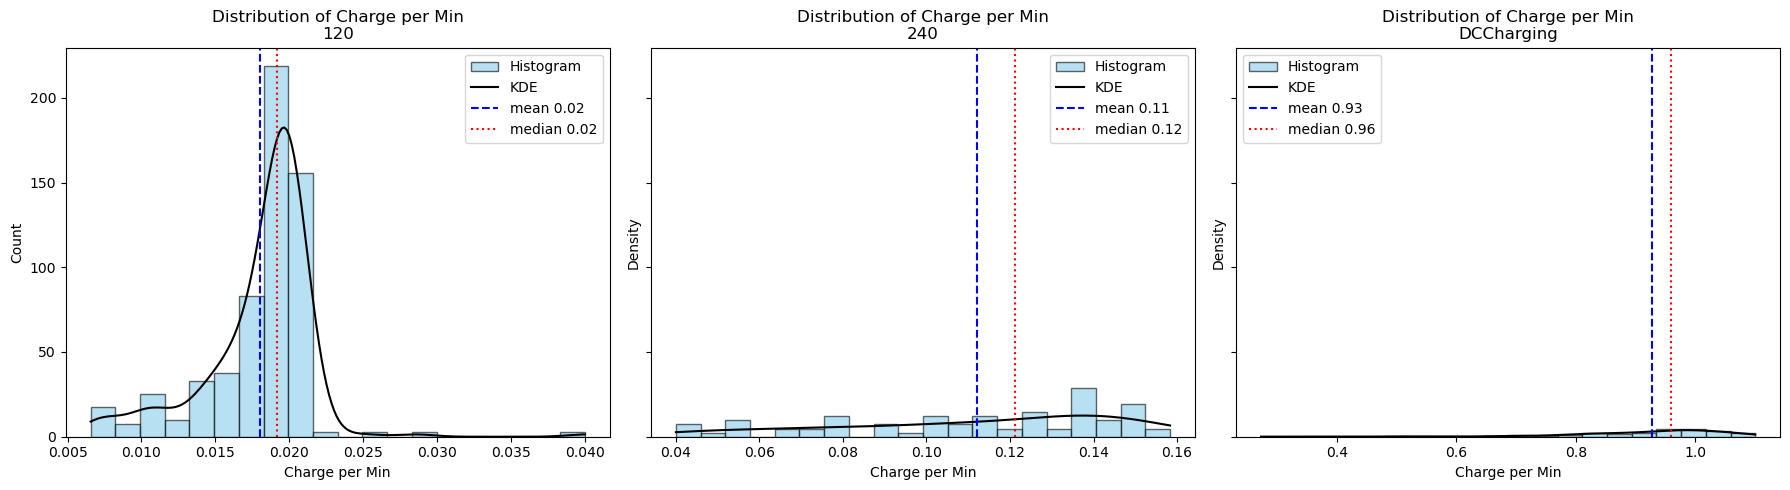

In [43]:
# --- Distribution of Charge per min ---

# Create a figure with 3 subplots, one for each charge_mode
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, mode in enumerate(['120', '240', 'DCCharging']):
    data_mode = charge_data_original.loc[charge_data_original['charge_mode'] == mode, 'charge_per_min']
    ax = axes[i]
    plot_hist_with_kde(data_mode, ax,
                       color='skyblue',
                       title=f"Distribution of Charge per Min\n{mode}",
                       xlabel='Charge per Min')

axes[0].set_ylabel('Count')  # common y-axis label
plt.tight_layout()
plt.show()


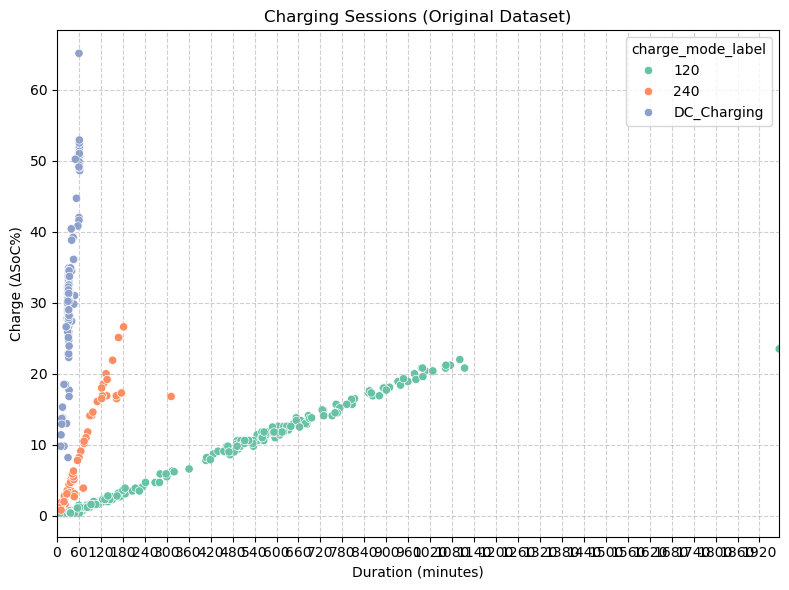

In [44]:
"""
Scatterplot of duration vs. charge,
colored by charge_mode (mapped to labels).
"""
import matplotlib.ticker as mticker

# Mapping of charge_mode
charge_mode_map = {
    '120': "120",
    '240': "240",
    'DCCharging': "DC_Charging"
}

charge_data_original = charge_data_original.copy()
charge_data_original["charge_mode_label"] = charge_data_original["charge_mode"].map(charge_mode_map)

# Define consistent color palette (matching Set2)
fixed_palette = {
    "120": "#66c2a5",       # greenish
    "240": "#fc8d62",       # orange
    "DC_Charging": "#8da0cb" # blue
}

# Define desired order for hues
hue_order = ["120", "240", "DC_Charging"]

# Compute derived features
max_duration = charge_data_original["duration_minutes"].max()
charge_data_original['charge'] = -charge_data_original['discharge']

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=charge_data_original,
    x="duration_minutes",
    y="charge",
    hue="charge_mode_label",
    hue_order=hue_order,     # ← Force order
    palette=fixed_palette,   # ← Consistent colors
    legend="auto"
)

plt.title("Charging Sessions (Original Dataset)")
plt.xlim(0, max_duration)
plt.xlabel("Duration (minutes)")
plt.ylabel("Charge (ΔSoC%)")
plt.grid(True)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(60))
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## Save data

In [46]:
if SAVE:
    # Save DataFrame
    charge_data.to_csv(file_path_csv, index=False)

## Merge

In [47]:
"""# TAKE DATA 
#data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_0_1EVpenalty/Generated_data/epoch_1800/EV_generated_data_1800.csv')
number = 1200
#data = pd.read_csv(f'./Generated_data/epoch_{number}/EV_generated_data_{number}.csv')
data =  pd.read_csv(f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')

# print columns
print(data.columns)

# load also trip_Data and charge_data and then filter data, keeping only rows present in trip_data and charge_data
trip_data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data__trip_cleaned.csv') 

#take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'
trip_data = trip_data[['id']]
charge_data_1 = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data__charge_cleaned.csv')

# take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'
charge_data_1 = charge_data_1[[ 'id']]


# keep rows that are present in ids of trip_data and charge_data
data['id'] = data.index

data = data[data['id'].isin(trip_data['id']) | data['id'].isin(charge_data_1['id'])]

#drop columns 'id'
data = data.drop(columns=['id'])

#when event = 1 --> set end_odo = odo 
#data.loc[data['event'] == 1, 'end_odo'] = data['odo']
data.loc[data['event'] == 1, 'km_driven'] = 0

# add in first position column 'vin', all rows with value -2.47174E+18 or -1.12313E+18
data.insert(0, 'vin', -2.47174E+18)

# map event 0 -> trip, 1 -> charge
data['event'] = data['event'].map({0: 'trip', 1: 'charge'})

'''# map charge_mode 1 -> 120, 2 -> 240, 3 -> DC Charging
data['charge_mode'] = data['charge_mode'].map({0: 0, 1: 120, 2: 240, 3: 'DC Charging'})'''
data.to_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data_cleaned.csv', index=False)"""

"# TAKE DATA \n#data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_0_1EVpenalty/Generated_data/epoch_1800/EV_generated_data_1800.csv')\nnumber = 1200\n#data = pd.read_csv(f'./Generated_data/epoch_{number}/EV_generated_data_{number}.csv')\ndata =  pd.read_csv(f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')\n\n# print columns\nprint(data.columns)\n\n# load also trip_Data and charge_data and then filter data, keeping only rows present in trip_data and charge_data\ntrip_data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data__trip_cleaned.csv') \n\n#take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'\ntrip_data = trip_data[['id']]\ncharge_data_1 = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data__charge_cleaned.csv')\n\n# take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','du

In [48]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5569 entries, 0 to 5568
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event                    5569 non-null   int64  
 1   charge_mode              5569 non-null   int64  
 2   duration_minutes         5569 non-null   float64
 3   km_driven                5569 non-null   float64
 4   charge                   5569 non-null   float64
 5   id                       5569 non-null   int64  
 6   delta_soc                5569 non-null   float64
 7   min_per_perc_of_battery  5569 non-null   float64
 8   charge_per_min           5569 non-null   float64
 9   soc                      5569 non-null   int64  
 10  end_soc                  5569 non-null   float64
 11  charge_mode_label        5569 non-null   object 
dtypes: float64(7), int64(4), object(1)
memory usage: 522.2+ KB
